# Assignment 5 - Hierarchical Clustering
- Course: 64060 - Machine Learning and Data Analytics
- Datasource - Cereals.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import cdist, pdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import files

# Upload the CSV file
print("Please upload your Cereals.csv file:")
uploaded = files.upload()

# Load the data
df = pd.read_csv('Cereals.csv')
print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")

Please upload your Cereals.csv file:


Saving Cereals.csv to Cereals (2).csv
Data loaded successfully!
Dataset shape: (77, 16)


In [ ]:
df_clean = df.dropna().copy()
print(f"Original shape: {df.shape}")
print(f"After removing missing values: {df_clean.shape}")

numeric_cols = ['calories', 'protein', 'fat', 'sodium', 'fiber',
                'carbo', 'sugars', 'potass', 'vitamins', 'shelf',
                'weight', 'cups', 'rating']
X = df_clean[numeric_cols].values

Original shape: (77, 16)
After removing missing values: (74, 16)


In [ ]:
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

Applying hierarchical clustering, on different linkage methods.

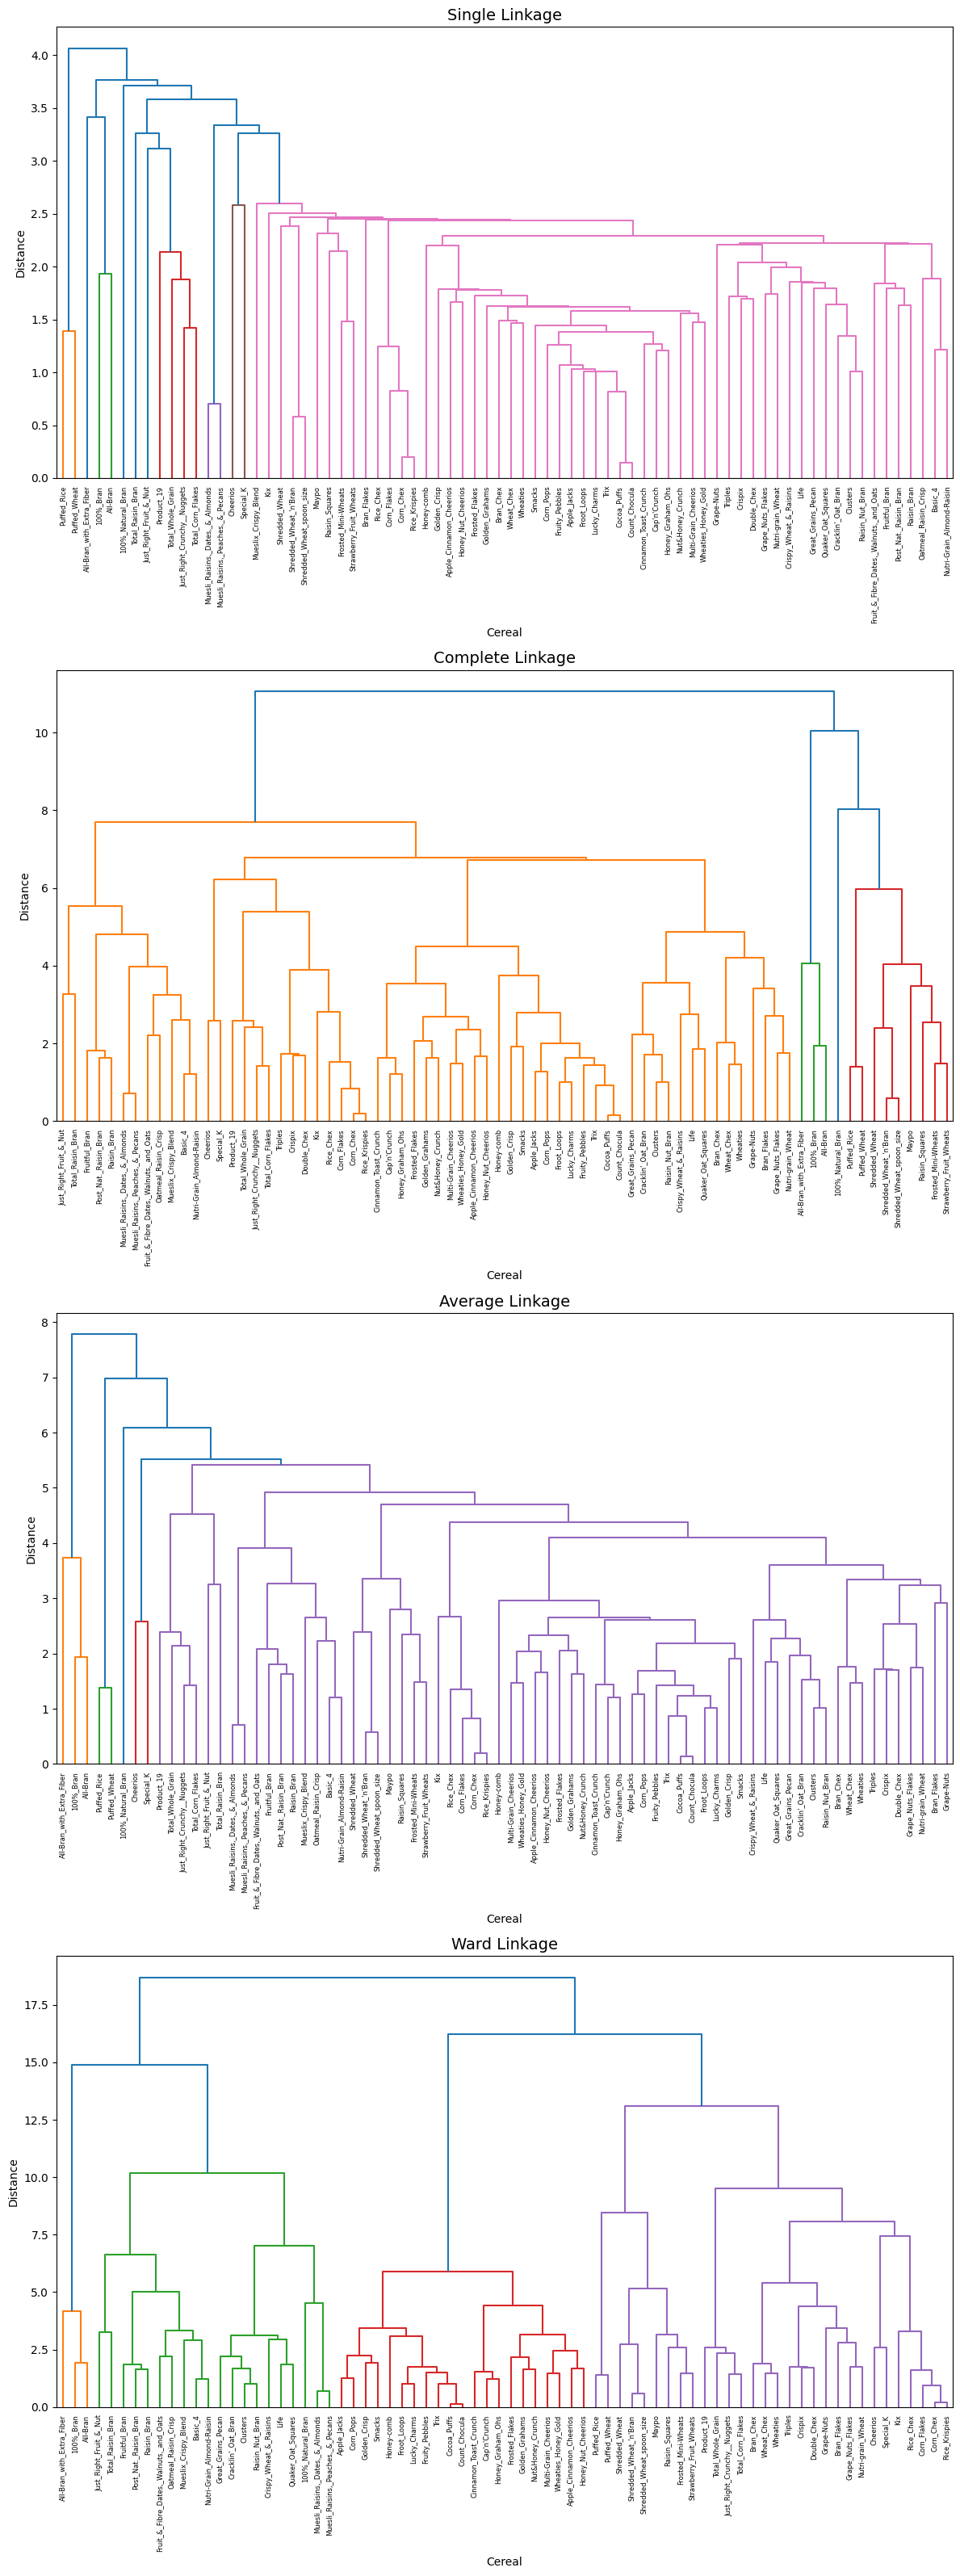

In [ ]:
linkage_methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(4, 1, figsize=(12, 32))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    # Calculate the linkage for each
    Z = linkage(X_normalized, method=method)
    # Create the graph.
    axes[idx].set_title(f'{method.capitalize()} Linkage', fontsize=14)
    dendrogram(Z, ax=axes[idx], labels=df_clean['name'].values, leaf_font_size=6)
    axes[idx].set_xlabel('Cereal')
    axes[idx].set_ylabel('Distance')

plt.tight_layout()
plt.show()

In [ ]:
print("Cophenetic Correlation by Linkage Method:")
for method in linkage_methods:
    Z = linkage(X_normalized, method=method)
    c, coph_dists = cophenet(Z, pdist(X_normalized))
    print(f'{method.capitalize()} Linkage: {c:.4f}')

Cophenetic Correlation by Linkage Method:
Single Linkage: 0.7305
Complete Linkage: 0.6750
Average Linkage: 0.8241
Ward Linkage: 0.5472


In [ ]:
best_method = 'average' #Picking average as it has 0.8241 cophenetic correlation.
Z_best = linkage(X_normalized, method=best_method)
print(f"Using {best_method} linkage for analysis")

Using average linkage for analysis


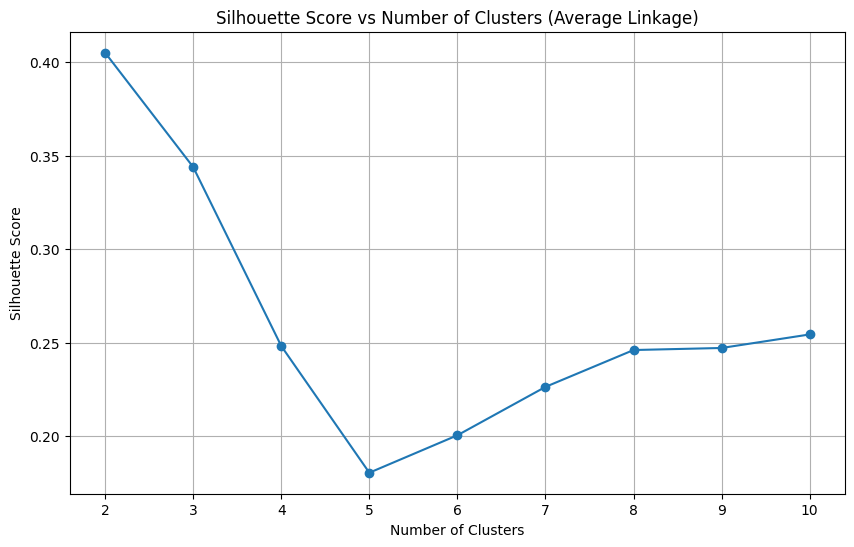

In [ ]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    clusters = fcluster(Z_best, k, criterion='maxclust')
    score = silhouette_score(X_normalized, clusters)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters (Average Linkage)')
plt.grid(True)
plt.show()

Picking the number of clusters based on metrics above.

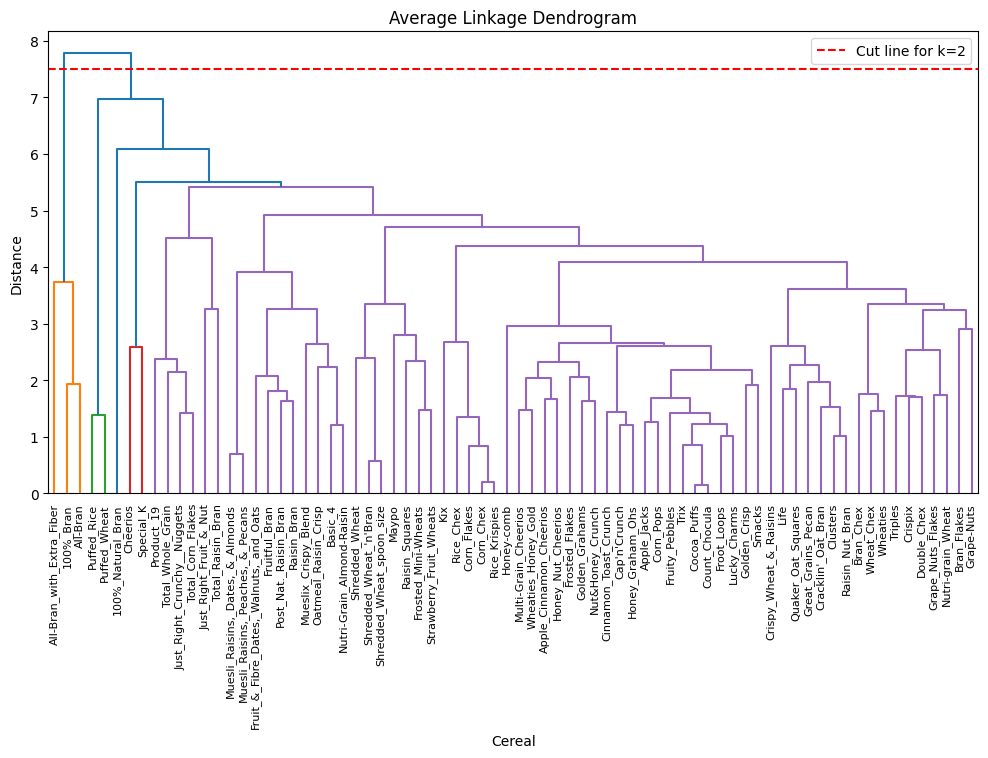

In [ ]:
plt.figure(figsize=(12, 6))
dendrogram(Z_best, labels=df_clean['name'].values, leaf_font_size=8)
plt.title(f'{best_method.capitalize()} Linkage Dendrogram')
plt.xlabel('Cereal')
plt.ylabel('Distance')
plt.axhline(y=7.5, color='r', linestyle='--', label='Cut line for k=2')
plt.legend()
plt.show()

Seeing the difference between clusters and doing further analysis

In [ ]:
optimal_k = 2  # From Silhouette Score analysis
clusters = fcluster(Z_best, optimal_k, criterion='maxclust')
df_clean['Cluster'] = clusters

print(f'\nCluster Distribution:')
print(df_clean['Cluster'].value_counts().sort_index())

cluster_summary = df_clean.groupby('Cluster')[numeric_cols].mean()
print('\nCluster Characteristics (Mean Values):')
print(cluster_summary.round(2))


Cluster Distribution:
Cluster
1     3
2    71
Name: count, dtype: int64

Cluster Characteristics (Mean Values):
         calories  protein   fat  sodium  fiber  carbo  sugars  potass  \
Cluster                                                                  
1           63.33     4.00  0.67  176.67   11.0   6.67    3.67  310.00   
2          108.87     2.45  1.01  161.76    1.8  15.07    7.25   89.58   

         vitamins  shelf  weight  cups  rating  
Cluster                                         
1           25.00   3.00    1.00  0.39   73.84  
2           29.23   2.18    1.03  0.84   41.04  


In [ ]:
np.random.seed(42)
partition_A_idx = df_clean.sample(frac=0.6, random_state=42).index
partition_B_idx = df_clean.drop(partition_A_idx).index

X_A = X_normalized[df_clean.index.isin(partition_A_idx)]
X_B = X_normalized[df_clean.index.isin(partition_B_idx)]

print(f"Partition A size: {len(X_A)}")
print(f"Partition B size: {len(X_B)}")

Partition A size: 44
Partition B size: 30


In [ ]:
Z_A = linkage(X_A, method=best_method)
clusters_A = fcluster(Z_A, optimal_k, criterion='maxclust')
Z_B = linkage(X_B, method=best_method)
clusters_B = fcluster(Z_B, optimal_k, criterion='maxclust')

In [ ]:
df_A = df_clean.loc[partition_A_idx].copy()
df_A['Cluster_A'] = clusters_A
# Get the mean of the *normalized* values for each cluster in A
centroids_A = df_A.groupby('Cluster_A')[numeric_cols].apply(lambda x: scaler.transform(x.values).mean(axis=0))

In [ ]:
df_B = df_clean.loc[partition_B_idx].copy()
centroid_matrix = np.array([centroids_A[i] for i in range(1, optimal_k + 1)])

# Calculate distances from B points to A's centroids
distances = cdist(X_B, centroid_matrix, metric='euclidean')
clusters_B_from_A = np.argmin(distances, axis=1) + 1 # +1 to match fcluster's 1-based indexing

In [45]:
df_B['Cluster_B_from_A'] = clusters_B_from_A
df_B['Cluster_B_independent'] = clusters_B

consistency = (df_B['Cluster_B_from_A'] == df_B['Cluster_B_independent']).mean()
print(f'\nStability Check:')
print(f'Consistency between A-based and B-independent clustering: {consistency:.2%}')

# Compare A-based assignments to the original full-dataset assignments
df_clean['Cluster_Full'] = clusters
df_B['Cluster_Full'] = df_clean.loc[partition_B_idx]['Cluster_Full']
consistency_full = (df_B['Cluster_Full'] == df_B['Cluster_B_from_A']).mean()
print(f'Consistency between full-data and A-based clustering (for partition B): {consistency_full:.2%}')


Stability Check:
Consistency between A-based and B-independent clustering: 16.67%
Consistency between full-data and A-based clustering (for partition B): 83.33%


In [46]:
health_metrics = cluster_summary[['fiber', 'protein', 'sugars', 'sodium', 'rating']]
health_metrics['health_score'] = (
    health_metrics['fiber'] +
    health_metrics['protein'] +
    health_metrics['rating'] -
    health_metrics['sugars'] -
    health_metrics['sodium']/100 # Arbitrary scale down for sodium's large values
)

print('\nHealth Score by Cluster:')
print(health_metrics[['fiber', 'protein', 'sugars', 'rating', 'health_score']].round(2))

healthiest_cluster = health_metrics['health_score'].idxmax()
print(f'\nHealthiest Cluster: {healthiest_cluster}')


Health Score by Cluster:
         fiber  protein  sugars  rating  health_score
Cluster                                              
1         11.0     4.00    3.67   73.84         83.41
2          1.8     2.45    7.25   41.04         36.42

Healthiest Cluster: 1


/tmp/ipython-input-3353484386.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  health_metrics['health_score'] = (


In [47]:
healthy_cereals = df_clean[df_clean['Cluster'] == healthiest_cluster][['name', 'fiber', 'protein', 'sugars', 'rating']]
print(f'\nCereals in Healthiest Cluster (Cluster {healthiest_cluster}):')
print(healthy_cereals.sort_values('rating', ascending=False))


Cereals in Healthiest Cluster (Cluster 1):
                        name  fiber  protein  sugars     rating
3  All-Bran_with_Extra_Fiber   14.0        4     0.0  93.704912
0                  100%_Bran   10.0        4     6.0  68.402973
2                   All-Bran    9.0        4     5.0  59.425505


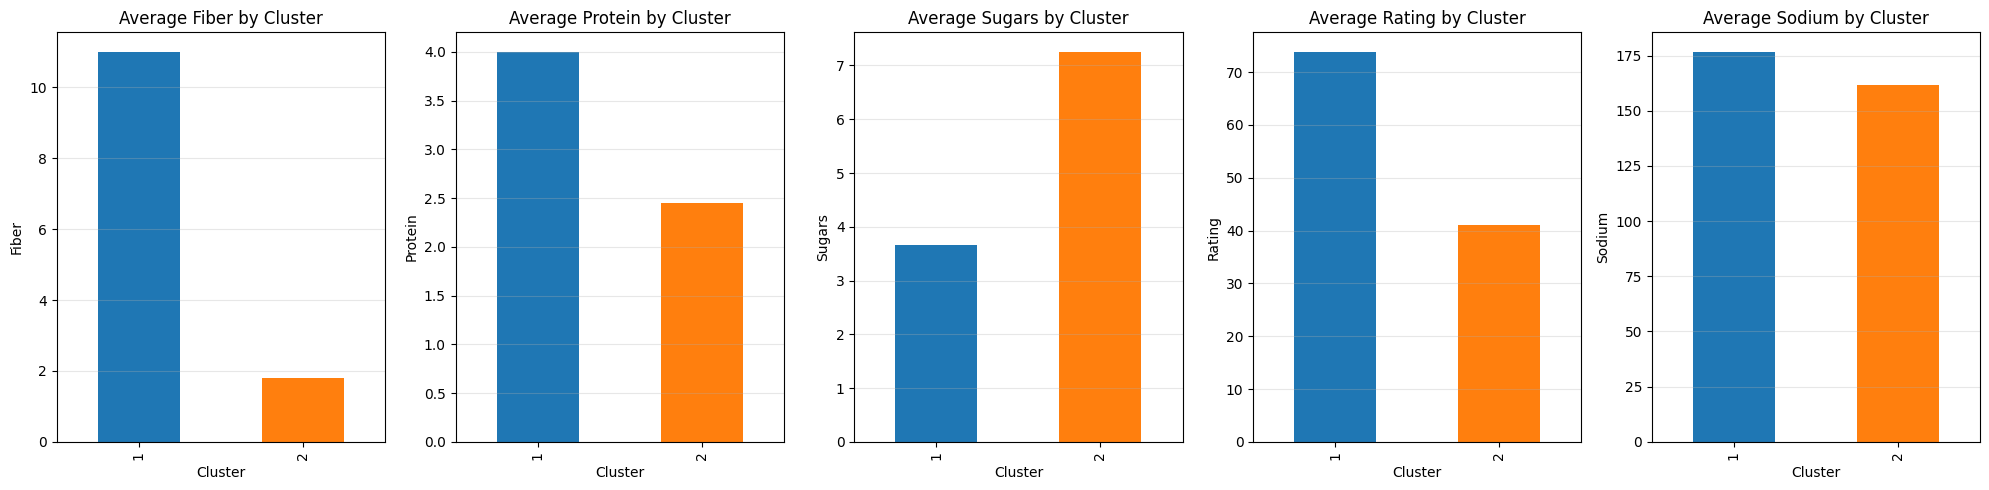

In [52]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

metrics_to_plot = [('fiber', 'Fiber'), ('protein', 'Protein'),
                   ('sugars', 'Sugars'), ('rating', 'Rating'), ('sodium', 'Sodium')]

for idx, (metric, label) in enumerate(metrics_to_plot):
    ax = axes[idx]
    cluster_summary[metric].plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title(f'Average {label} by Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(label)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Ending Comments

In [53]:
print('\n=== Should Data Be Normalized? ===')
print('YES - Normalization is necessary because:')
print('- Variables have different scales (sodium: 0-320, fiber: 0-14)')
print('- Without normalization, high-scale variables dominate distance calculations')
print('- StandardScaler ensures all nutritional features contribute equally')
print('- Critical for meaningful cluster interpretation')
print('\n=== What cereal should be picked? ===')
print('- Based on the analysis above most cluster 1 with three cereals is the healthy choice.')
print('- As it has higher protien, low sugar, high fiber count and great rating.')
print('- With almost the same sodium count as in cluster 2.')


=== Should Data Be Normalized? ===
YES - Normalization is necessary because:
- Variables have different scales (sodium: 0-320, fiber: 0-14)
- Without normalization, high-scale variables dominate distance calculations
- StandardScaler ensures all nutritional features contribute equally
- Critical for meaningful cluster interpretation

=== What cereal should be picked? ===
- Based on the analysis above most cluster 1 with three cereals is the healthy choice.
- As it has higher protien, low sugar, high fiber count and great rating.
- With almost the same sodium count as in cluster 2.
